# IMPORT LIBRARY

In [ ]:
%%time
import pandas as pd # Import library Pandas untuk manipulasi data tabel.
import numpy as np # Import NumPy untuk operasi numerik dan array.
import seaborn as sns # Import Seaborn untuk visualisasi data statistik.
from matplotlib import pyplot as plt # Import pyplot dari Matplotlib untuk membuat grafik.
sns.set() # Mengaktifkan style default Seaborn.
%matplotlib inline

CPU times: user 1.37 s, sys: 143 ms, total: 1.52 s
Wall time: 1.46 s


# LOAD DATASET

In [ ]:
df = pd.read_csv ("Dataset_Kemiskinan (1).csv")

# A. BUSINESS UNDERSTANDING

**Latar Belakang**

> Kemiskinan masih menjadi salah satu tantangan utama pembangunan di Indonesia. Tingkat kemiskinan antar kabupaten/kota sangat bervariasi dan dipengaruhi oleh banyak faktor sosial-ekonomi, seperti tingkat pendidikan, kesehatan, akses terhadap infrastruktur dasar (sanitasi dan air minum), daya beli masyarakat, serta kondisi ketenagakerjaan. Memahami pola dan hubungan antar faktor-faktor tersebut penting sebagai dasar perumusan kebijakan pengentasan kemiskinan yang lebih tepat sasaran.

**Rumusan Masalah**

> 1. Bagaimana persebaran dan karakteristik tingkat kemiskinan di berbagai kabupaten/kota di Indonesia?
> 2. Faktor-faktor sosial-ekonomi apa saja yang memiliki hubungan paling kuat dengan tingkat kemiskinan?
> 3. Wilayah mana saja yang perlu mendapat perhatian/prioritas intervensi karena tingkat kemiskinannya tinggi?

**Tujuan Analisis**

> 1. Melakukan pembersihan (cleaning) data agar layak digunakan untuk analisis lebih lanjut.
> 2. Mengeksplorasi dan memvisualisasikan pola kemiskinan serta indikator sosial-ekonomi terkait di tingkat kabupaten/kota.
> 3. Mengidentifikasi variabel yang paling berkorelasi dengan kemiskinan sebagai dasar rekomendasi kebijakan maupun pemodelan prediktif lanjutan.

**Target/Variabel Utama**

> **Kemiskinan** (persentase penduduk miskin) merupakan variabel target dalam analisis ini, dengan variabel pendukung berupa RLS, Pengeluaran, IPM, UHH, Sanitasi, AirMinum, TPT, dan TPAK.


# B. DATA UNDERSTANDING

### B.1 Menampilkan baris pada dasaset

In [ ]:
df.head() # menampilkan 5 baris pertama dari dataset.

,Provinsi,KabKota,Kemiskinan,RLS,Pengeluaran,IPM,UHH,Sanitasi,AirMinum,TPT,TPAK
0,ACEH,Simeulue,8.180556,9.480000,7148,66.41,65.28,71.56,87.45,2.576389,71.15
1,ACEH,Aceh Singkil,20.360000,3.805556,8776,69.22,67.43,69.56,78.58,8.360000,62.85
2,ACEH,Aceh Selatan,13.180000,3.944444,8180,67.44,64.04,62.55,79.65,6.460000,60.85
3,ACEH,Aceh Tenggara,13.410000,4.215278,8030,69.44,68.22,62.71,86.71,6.430000,69.62
4,ACEH,Aceh Timur,14.450000,8.210000,8577,67.83,68.74,66.75,83.16,7.130000,59.48


In [ ]:
df.tail() #menampilkan 5 baris terakhir dari dataset

,Provinsi,KabKota,Kemiskinan,RLS,Pengeluaran,IPM,UHH,Sanitasi,AirMinum,TPT,TPAK
527,PAPUA,Intan Jaya,41.66,3.09,5328,48.34,65.69,0.36,35.01,1.430000,75.75
528,PAPUA,Deiyai,40.59,3.25,4673,49.96,65.36,0.00,85.23,54.861111,85.01
529,PAPUA,Kota Jayapura,11.39,11.57,14937,NaN,70.52,85.31,97.10,5.048611,63.75
530,PAPUA,Deiyai,40.59,3.25,4673,49.96,65.36,0.00,85.23,54.861111,85.01
531,PAPUA,Kota Jayapura,11.39,11.57,14937,NaN,70.52,85.31,97.10,5.048611,63.75


### B.2 Menampilkan Jumlah Dataset

In [ ]:
df.shape # mengetahui ukuran dataset (jumlah baris, jumlah kolom).

(532, 11)

In [ ]:
df.size # mengetahui total seluruh elemen data dalam dataframe. (jumlah baris x jumlah kolom)

5852

### B.3 Menampilkan Fitur Dataset

In [ ]:
df.columns.tolist() # menampilkan nama kolom atau fitur dalam dataset

['Provinsi',
 'KabKota',
 'Kemiskinan',
 'RLS',
 'Pengeluaran',
 'IPM',
 'UHH',
 'Sanitasi',
 'AirMinum',
 'TPT',
 'TPAK']

Penjelasan fitur atau Kolom:
1. **Provinsi**: Menunjukkan nama provinsi tempat data berasal, digunakan untuk identifikasi wilayah tingkat provinsi.

2. **KabKota**: Menunjukan nama kabupaten atau kota provinsi tertentu, digunakan sebagai identitas wilayah yang dianalisis.

3. **Kemiskinan**: Menunjukan jumlah kemiskinan disuatu daerah (variabel utama)

4. **RLS**: **Rata-rata Lama Sekolah**. Menunjukkan rata rata jumlah tahun pendidikan yang ditempuh penduduk. Semakin tinggi RLS biasanya kualitas pendidikan lebih baik.

5. **Pengeluaran**: Rata-rata pengeluaran per kapita masyarakat.

6. **IPM**: **Indeks Pembangunan Manusia**. Indikator gabungan yang mengukur kualitas hidup berdasarkan pendidikan, kesehatan, dan ekonomi.

7. **UHH**: **Umur Harapan Hidup**. Menunjukkan rata-rata perkiraan usia hidup masyarakat. Digunakan untuk mengukur kualitas kesehatan daerah.

8. **Sanitasi**: Persentase akses sanitasi layak. Menggambarkan kondisi kebersihan dan kesehatan lingkungan masyarakat.

9. **AirMinum**: Persentase akses air minum layak. Menunjukkan ketersediaan air bersih bagi masyarakat.

10. **TPT**: Tingkat Pengangguran Terbuka. Persentase angkatan kerja yang belum memiliki pekerjaan. Digunakan untuk melihat kondisi ketenagakerjaan.

11. **TPAK**: Tingkat Partisipasi Angkatan Kerja. Persentase penduduk usia kerja yang aktif bekerja atau mencari kerja. Menggambarkan aktivitas ekonomi masyarakat.



### B.4 Menampilkan Informasi Dataset

In [ ]:
df.info() # menampilkan informasi lengkap dataframe.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 532 entries, 0 to 531
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Provinsi     532 non-null    object 
 1   KabKota      532 non-null    object 
 2   Kemiskinan   532 non-null    float64
 3   RLS          532 non-null    float64
 4   Pengeluaran  532 non-null    int64  
 5   IPM          526 non-null    float64
 6   UHH          527 non-null    float64
 7   Sanitasi     531 non-null    float64
 8   AirMinum     529 non-null    float64
 9   TPT          532 non-null    float64
 10  TPAK         532 non-null    float64
dtypes: float64(8), int64(1), object(2)
memory usage: 45.8+ KB


### B.5 Menampilkan Ringkasan Statistik Deskriptif

In [ ]:
df.describe() # menampilkan ringkasan statistik deskriptif dari kolom numerik pada dataframe.

,Kemiskinan,RLS,Pengeluaran,IPM,UHH,Sanitasi,AirMinum,TPT,TPAK
count,532.000000,532.000000,532.000000,526.000000,527.000000,531.000000,529.000000,532.000000,532.000000
mean,12.314461,6.646480,10734.208647,69.927471,69.674364,77.200472,85.481478,6.683558,69.428402
std,36.890945,2.761811,6737.762078,6.566927,3.489820,18.810707,15.235952,13.054782,6.395868
min,0.150000,0.268750,3976.000000,32.840000,55.430000,0.000000,0.000000,0.000000,56.390000
25%,4.623264,3.909722,8576.000000,66.660000,67.360000,70.190000,79.650000,2.317083,64.975000
50%,7.537361,7.310000,10207.000000,69.615000,70.010000,81.890000,89.960000,3.525417,68.890000
75%,13.342500,8.480000,11795.750000,73.112500,72.065000,89.935000,96.570000,5.450000,72.352500
max,834.000000,12.510000,117166.000000,87.180000,77.730000,99.970000,100.000000,99.305556,97.930000


untuk **indikasi awal adanya outlier**, perhatikan:


*   min & max = apakah terlalu jauh dari rata-rata?
*   mean vs median (50%) = kalau jauh beda, bisa ada outlier.
*   std (standar deviasi) = kalau besar banget, data tersebar ekstrem.









### B.6 Mengecek Jumlah Nilai Unik pada Kolom

In [ ]:
df.nunique() # menghitung jumlah nilai unik (distinct values) di setiap kolom pada DataFrame pandas.

,0
Provinsi,34
KabKota,514
Kemiskinan,444
RLS,334
Pengeluaran,499
IPM,436
UHH,397
Sanitasi,486
AirMinum,462
TPT,371


### B.7 Pengecekan Missing Value

In [ ]:
df.isnull() # True kalau datanya kosong (null), False kalau ada isi

,Provinsi,KabKota,Kemiskinan,RLS,Pengeluaran,IPM,UHH,Sanitasi,AirMinum,TPT,TPAK
0,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...
527,False,False,False,False,False,False,False,False,False,False,False
528,False,False,False,False,False,False,False,False,False,False,False
529,False,False,False,False,False,True,False,False,False,False,False
530,False,False,False,False,False,False,False,False,False,False,False


In [ ]:
df.isnull().sum() # menghitung jumlah nilai kosong (missing value / NaN) di setiap kolom.

,0
Provinsi,0
KabKota,0
Kemiskinan,0
RLS,0
Pengeluaran,0
IPM,6
UHH,5
Sanitasi,1
AirMinum,3
TPT,0


<Axes: >

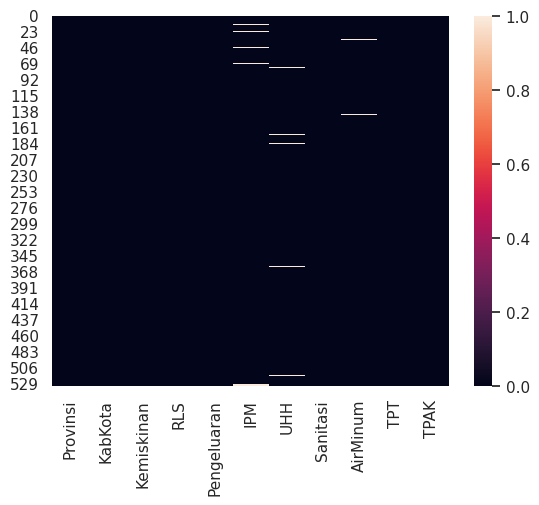

In [ ]:
sns.heatmap(df.isnull()) # visualisasi miss value

### B.8 Pengecekan Outlier

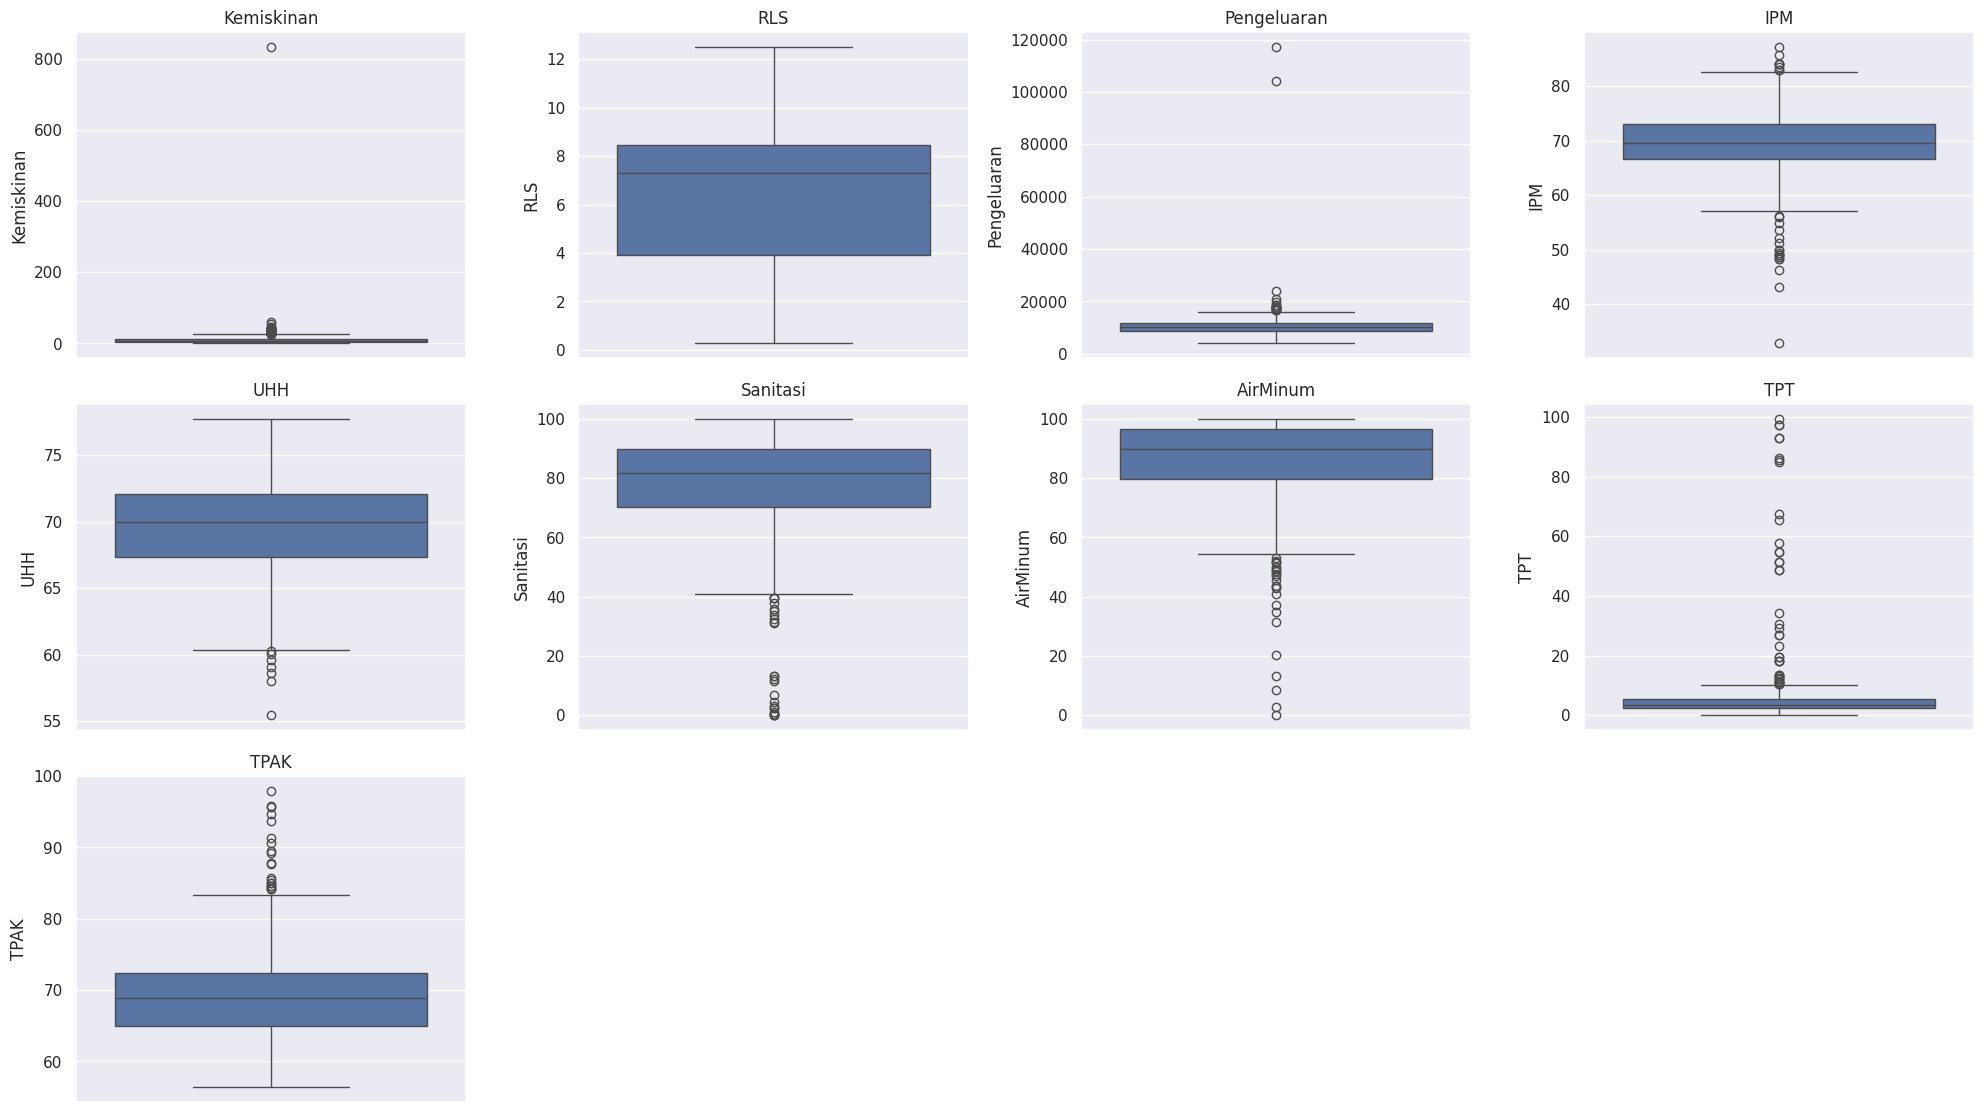

In [ ]:
# Memilih kolom numerik
numeric_cols = df.select_dtypes(include=['number']).columns

# Membuat boxplot
plt.figure(figsize=(20, 15))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(4, 4, i)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

In [ ]:
# Menggunakan IQR untuk menentukan jumlah masing-masing outlier

num_cols = df.select_dtypes(include='number').columns

print("Jumlah Outlier (IQR Method):")

for col in num_cols:
    Q1, Q3 = df[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1

    outliers = ((df[col] < Q1 - 1.5 * IQR) | (df[col] > Q3 + 1.5 * IQR)).sum()

    print(f"{col}: {outliers}")

Jumlah Outlier (IQR Method):
Kemiskinan: 47
RLS: 0
Pengeluaran: 17
IPM: 27
UHH: 7
Sanitasi: 25
AirMinum: 23
TPT: 42
TPAK: 20


In [ ]:
# Menampilkan 10 data dengan nilai Kemiskinan tertinggi untuk mengidentifikasi outlier dan memeriksa adanya anomali data.

df.sort_values('Kemiskinan', ascending=False)[
    ['Provinsi','KabKota','Kemiskinan']
].head(10)

,Provinsi,KabKota,Kemiskinan
62,SUMATERA UTARA,Kota Medan,834.000
403,SULAWESI TENGAH,Morowali,59.375
254,JAWA TIMUR,Situbondo,54.375
114,SUMATERA SELATAN,Banyu Asin,46.875
103,JAMBI,Tanjung Jabung Barat,46.875
374,KALIMANTAN TIMUR,Kutai Timur,43.125
88,RIAU,Pelalawan,41.875
527,PAPUA,Intan Jaya,41.660
528,PAPUA,Deiyai,40.590
530,PAPUA,Deiyai,40.590


In [ ]:
# Menampilkan 10 data dengan nilai TPT tertinggi untuk mengidentifikasi outlier dan memeriksa adanya nilai yang tidak wajar.

df.sort_values('TPT', ascending=False)[
    ['Provinsi','KabKota','TPT']
].head(10)

,Provinsi,KabKota,TPT
449,SULAWESI TENGGARA,Konawe Kepulauan,99.305556
474,MALUKU,Maluku Barat Daya,97.222222
294,BALI,Bangli,97.222222
508,PAPUA,Puncak Jaya,93.055556
308,NUSA TENGGARA TIMUR,Sumba Barat,93.055556
123,SUMATERA SELATAN,Kota Pagar Alam,86.111111
475,MALUKU,Buru Selatan,85.416667
502,PAPUA,Jayawijaya,84.722222
325,NUSA TENGGARA TIMUR,Nagekeo,67.361111
525,PAPUA,Puncak,65.277778


**TEMUAN:**

> Berdasarkan hasil visualisasi boxplot dan deteksi IQR, sebagian besar variabel menunjukkan adanya outlier yang mencerminkan heterogenitas kondisi sosial-ekonomi antar kabupaten/kota di Indonesia. Outlier pada variabel Pengeluaran, IPM, UHH, Sanitasi, Air Minum, dan TPAK masih berada dalam rentang yang logis serta dapat merepresentasikan kondisi nyata suatu wilayah. Oleh karena itu, nilai-nilai tersebut tidak dianggap sebagai kesalahan data dan tetap dipertahankan untuk menjaga informasi penting dalam dataset.

> Pada variabel Kemiskinan, ditemukan 47 outlier. Sebagian besar nilai outlier masih tergolong realistis, terutama pada wilayah dengan tingkat kemiskinan tinggi seperti beberapa kabupaten di Papua dan daerah tertinggal lainnya. Namun, ditemukan satu nilai yang sangat ekstrem yaitu Kemiskinan sebesar 834 pada Kota Medan, yang jauh berbeda dari distribusi data lainnya dan terindikasi sebagai kesalahan pencatatan atau kesalahan format desimal.

> Pada variabel TPT (Tingkat Pengangguran Terbuka) ditemukan 42 outlier dengan beberapa nilai mencapai lebih dari 90%, seperti Konawe Kepulauan (99,31%), Bangli (97,22%), dan Maluku Barat Daya (97,22%). Nilai tersebut berada jauh di luar rentang TPT yang umumnya ditemukan pada data ketenagakerjaan sehingga berpotensi memberikan pengaruh yang berlebihan terhadap analisis statistik maupun proses pemodelan.

### B.9 Pengecekan Data Duplikat

In [ ]:
df.duplicated().sum()

np.int64(16)

# C. DATA CLEANING

### C.1 Penanganan Missing Value

**PERHATIKAN:**

1. Jika persentasenya kecil (misalnya < 5%), biasanya bisa diisi dengan nilai statistik seperti mean atau median.

2. Untuk data numerik biasanya menggunakan:
> **Median** jika terdapat banyak outlier disetiap fitur yang ada miss valuenya atau distribusi tidak normal **(disarankan)**.
> **Mean** jika distribusi data normal (tidak ada outlier) **(tidak disarankan)**.


3. Jika jumlah baris dataset besar maka bisa menggunakan DROP karena missing sedikit **(pertimbangkan)**.


Penanganan Missing Value dengan **Imputasi MEDIAN**

In [ ]:
# Pengisian kolom Numerik
num_cols = df.select_dtypes(include='number').columns

df[num_cols] = df[num_cols].fillna(df[num_cols].median())

Penanganan Missing Value dengan **Menghapus (DROP)**

In [ ]:
df.dropna(inplace=True)

### C.2 Validasi Penanganan Missing Value

In [ ]:
df.isnull().sum()

,0
Provinsi,0
KabKota,0
Kemiskinan,0
RLS,0
Pengeluaran,0
IPM,0
UHH,0
Sanitasi,0
AirMinum,0
TPT,0


<Axes: >

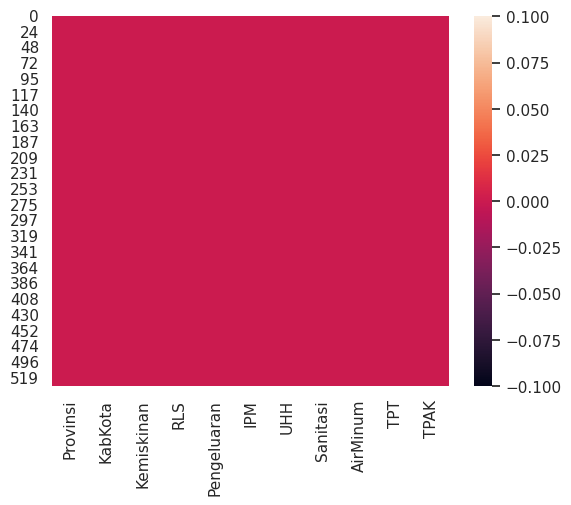

In [ ]:
sns.heatmap(df.isnull())

### C.3 Penanganan Outlier

**PERHATIKAN:**

**Penanganan outlier itu tergantung tujuan analisis**. Di data seperti kemiskinan/indikator (IPM, RLS, dll), biasanya jangan asal dihapus, karena bisa jadi itu data daerah “ekstrem” yang justru penting.

**BEBERAPA METODE PENANGANAN OUTLIER:**

**1. Menghapus Outlier (Capping/Hapus Baris)**

> Dipakai kalau yakin outlier itu noise atau error data.

> ⚠️ Kekurangan: data bisa berkurang banyak

In [ ]:
for col in num_cols:
    Q1, Q3 = df[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df = df[(df[col] >= lower) & (df[col] <= upper)]

**2. Capping / Winsorizing (RECOMMENDED)**

> Outlier tidak dihapus, tapi dibatasi ke batas atas/bawah

In [ ]:
for col in num_cols:
    Q1, Q3 = df[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = df[col].clip(lower, upper)

Berdasarkan temuan pada pengecekan outlier, penanganan outlier difokuskan pada:

- Koreksi nilai Kemiskinan Kota Medan dari 834 menjadi 8,34 karena terindikasi sebagai kesalahan data.
- Clipping pada variabel TPT untuk membatasi pengaruh nilai ekstrem yang berada di luar rentang logis.

Sementara itu, outlier pada variabel lainnya tetap dipertahankan karena dianggap merepresentasikan variasi kondisi sosial-ekonomi yang nyata antar wilayah dan masih memiliki nilai analitis dalam penelitian.

In [ ]:
# Mengoreksi nilai Kemiskinan Kota Medan yang teridentifikasi sebagai kesalahan pencatatan data.

mask_medan = (
    (df['Provinsi'] == 'SUMATERA UTARA') &
    (df['KabKota'] == 'Kota Medan') &
    (df['Kemiskinan'] == 834)
)

df.loc[mask_medan, 'Kemiskinan'] = 8.34

# Cek hasil
print(df.loc[mask_medan, ['Provinsi', 'KabKota', 'Kemiskinan']])

          Provinsi     KabKota  Kemiskinan
62  SUMATERA UTARA  Kota Medan        8.34


In [ ]:
# Penanganan outlier untuk TPT dengan diclip

num_cols = ['TPT']

for col in num_cols:
    Q1, Q3 = df[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] =  df[col].clip(lower, upper)

### C.4 Validasi Penanganan Outlier

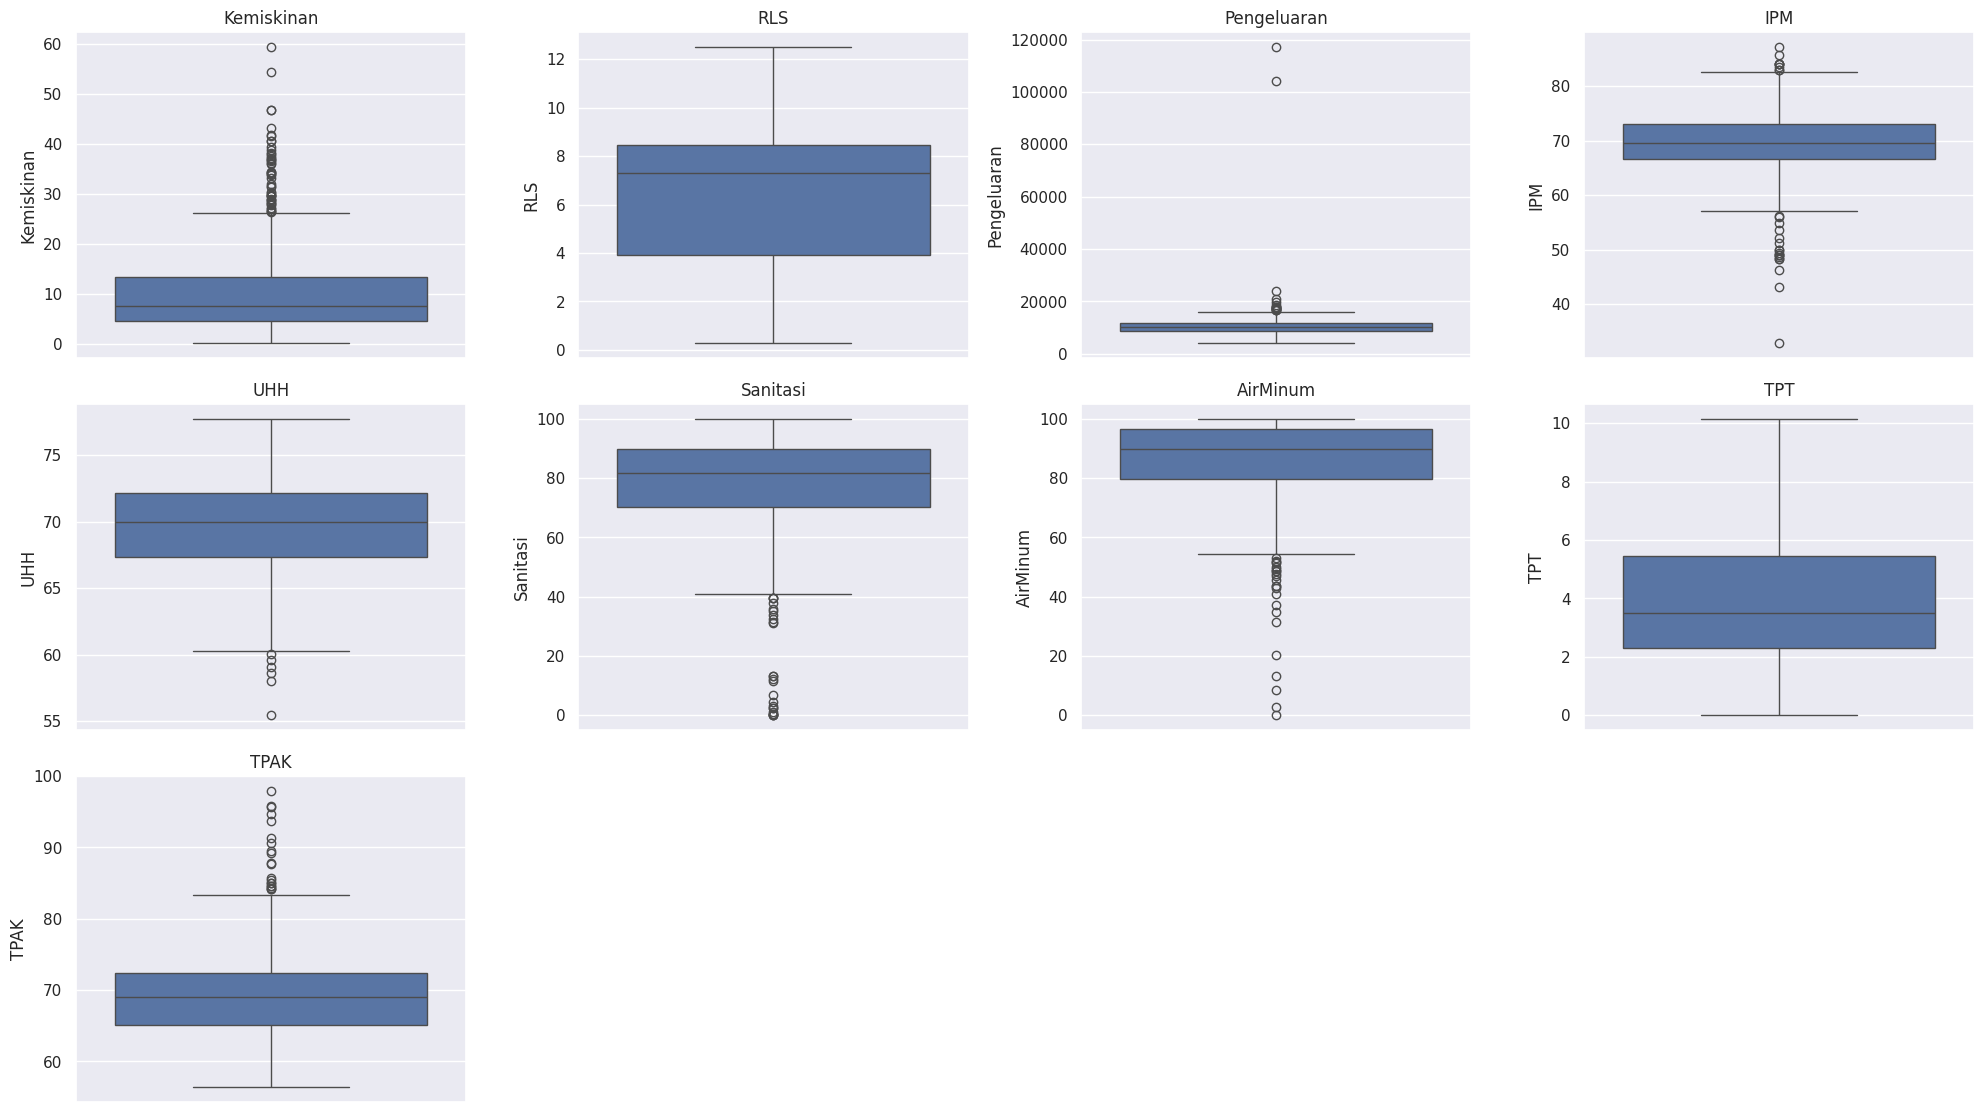

In [ ]:
# Memilih kolom numerik
numeric_cols = df.select_dtypes(include=['number']).columns

# Membuat boxplot
plt.figure(figsize=(20, 15))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(4, 4, i)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

**PENJELASAN:**

> Berdasarkan deteksi outlier menggunakan metode Interquartile Range (IQR), ditemukan beberapa nilai yang berada di luar batas bawah dan batas atas pada sejumlah variabel. Namun, tidak seluruh outlier ditangani karena sebagian besar masih merepresentasikan kondisi nyata antar wilayah di Indonesia yang memiliki karakteristik sosial-ekonomi yang beragam. Nilai ekstrem pada variabel seperti Kemiskinan, Pengeluaran, IPM, Sanitasi, Air Minum, dan TPAK masih berada dalam rentang yang logis dan dapat mencerminkan kondisi riil suatu daerah, sehingga tetap dipertahankan agar informasi penting dalam data tidak hilang.

> Pada variabel Kemiskinan ditemukan satu nilai sebesar 834 pada Kota Medan yang jauh berbeda dibandingkan distribusi data lainnya. Setelah dilakukan pemeriksaan terhadap pola data, nilai tersebut terindikasi sebagai kesalahan pencatatan atau kesalahan format desimal. Oleh karena itu, nilai tersebut dikoreksi menjadi 8,34 sesuai dengan format dan rentang nilai kemiskinan pada dataset.

> Sementara itu, variabel Tingkat Pengangguran Terbuka (TPT) memiliki beberapa nilai yang sangat tinggi hingga mencapai lebih dari 90%, yang berada di luar rentang yang umum ditemukan pada indikator TPT. Nilai-nilai tersebut berpotensi memberikan pengaruh yang berlebihan terhadap proses analisis dan pemodelan. Oleh karena itu, dilakukan penanganan outlier menggunakan metode clipping (winsorization), yaitu membatasi nilai yang melebihi batas atas IQR menjadi nilai batas atas tersebut. Pendekatan ini dipilih agar jumlah data tetap terjaga sekaligus mengurangi pengaruh nilai ekstrem terhadap hasil analisis.

### C.5 Penanganan Data Duplikat

In [ ]:
df.drop_duplicates(inplace=True)

### C.6 Validasi Penanganan Data Duplikat

In [ ]:
df.duplicated().sum()

np.int64(0)

# SAVE DATASET CLEAN

In [ ]:
df.to_csv('dataset_kemiskinan_clean.csv', index=False)

# KORELASI VARIABEL

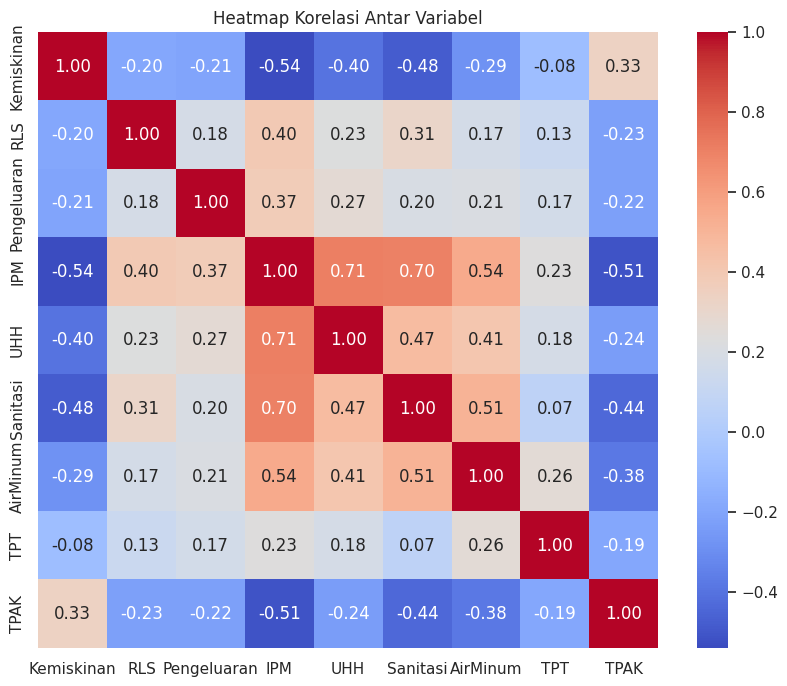

In [ ]:
plt.figure(figsize=(10,8))

corr = df.corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Heatmap Korelasi Antar Variabel')
plt.show()

**HUBUNGAN VARIABEL TARGET KEMISKINAN**

**Insight:**
> Berdasarkan hasil analisis korelasi, sebagian besar variabel memiliki hubungan negatif dengan tingkat kemiskinan. Variabel yang memiliki hubungan paling kuat dengan kemiskinan adalah IPM (-0,54), Sanitasi (-0,48), dan UHH (-0,40). Temuan ini mengindikasikan bahwa daerah dengan kualitas pembangunan manusia yang lebih baik, kondisi kesehatan yang lebih baik, serta akses sanitasi yang memadai cenderung memiliki tingkat kemiskinan yang lebih rendah.

> Selain itu, Air Minum (-0,29), Pengeluaran (-0,21), dan RLS (-0,20) juga menunjukkan hubungan negatif terhadap kemiskinan, meskipun dengan kekuatan yang lebih lemah. Hal ini mengindikasikan bahwa peningkatan daya beli masyarakat, tingkat pendidikan, serta akses air minum layak turut berkontribusi terhadap penurunan tingkat kemiskinan. Sementara itu, TPAK (0,33) memiliki hubungan positif dengan kemiskinan, yang menunjukkan bahwa tingginya partisipasi angkatan kerja tidak selalu mencerminkan kondisi ekonomi yang lebih baik karena sebagian masyarakat mungkin bekerja pada sektor informal atau pekerjaan berproduktivitas rendah. Adapun TPT (-0,08) memiliki korelasi yang sangat lemah sehingga menunjukkan bahwa tingkat pengangguran terbuka dalam dataset ini tidak memiliki hubungan yang signifikan terhadap tingkat kemiskinan.


**HUBUNGAN ANTAR VARIABEL INDEPENDEN**

**Insight:**
> Hasil korelasi antar variabel independen menunjukkan adanya beberapa hubungan yang cukup kuat. Korelasi tertinggi ditemukan antara IPM dan UHH (0,71) serta IPM dan Sanitasi (0,70). Hal ini menunjukkan bahwa wilayah dengan kualitas pembangunan manusia yang tinggi umumnya juga memiliki kondisi kesehatan yang lebih baik dan akses sanitasi yang lebih memadai. Selain itu, terdapat korelasi positif yang cukup kuat antara IPM dan Air Minum (0,54) serta Sanitasi dan Air Minum (0,51), yang mengindikasikan bahwa kualitas infrastruktur dasar dan layanan publik cenderung berkembang secara bersamaan.

> Secara umum, pola korelasi tersebut menunjukkan bahwa indikator pembangunan manusia, kesehatan, dan akses terhadap fasilitas dasar saling berkaitan erat. Daerah yang memiliki akses sanitasi dan air minum yang baik cenderung memiliki kualitas hidup yang lebih tinggi, yang kemudian tercermin pada peningkatan nilai IPM dan UHH. Meskipun terdapat beberapa korelasi yang cukup kuat, tidak ditemukan korelasi yang sangat tinggi (di atas 0,80), sehingga hubungan antar variabel masih berada pada tingkat yang dapat diterima dan tetap memberikan informasi yang berbeda dalam proses analisis maupun pemodelan.


# EXPLORATORY DATA ANALYSIS

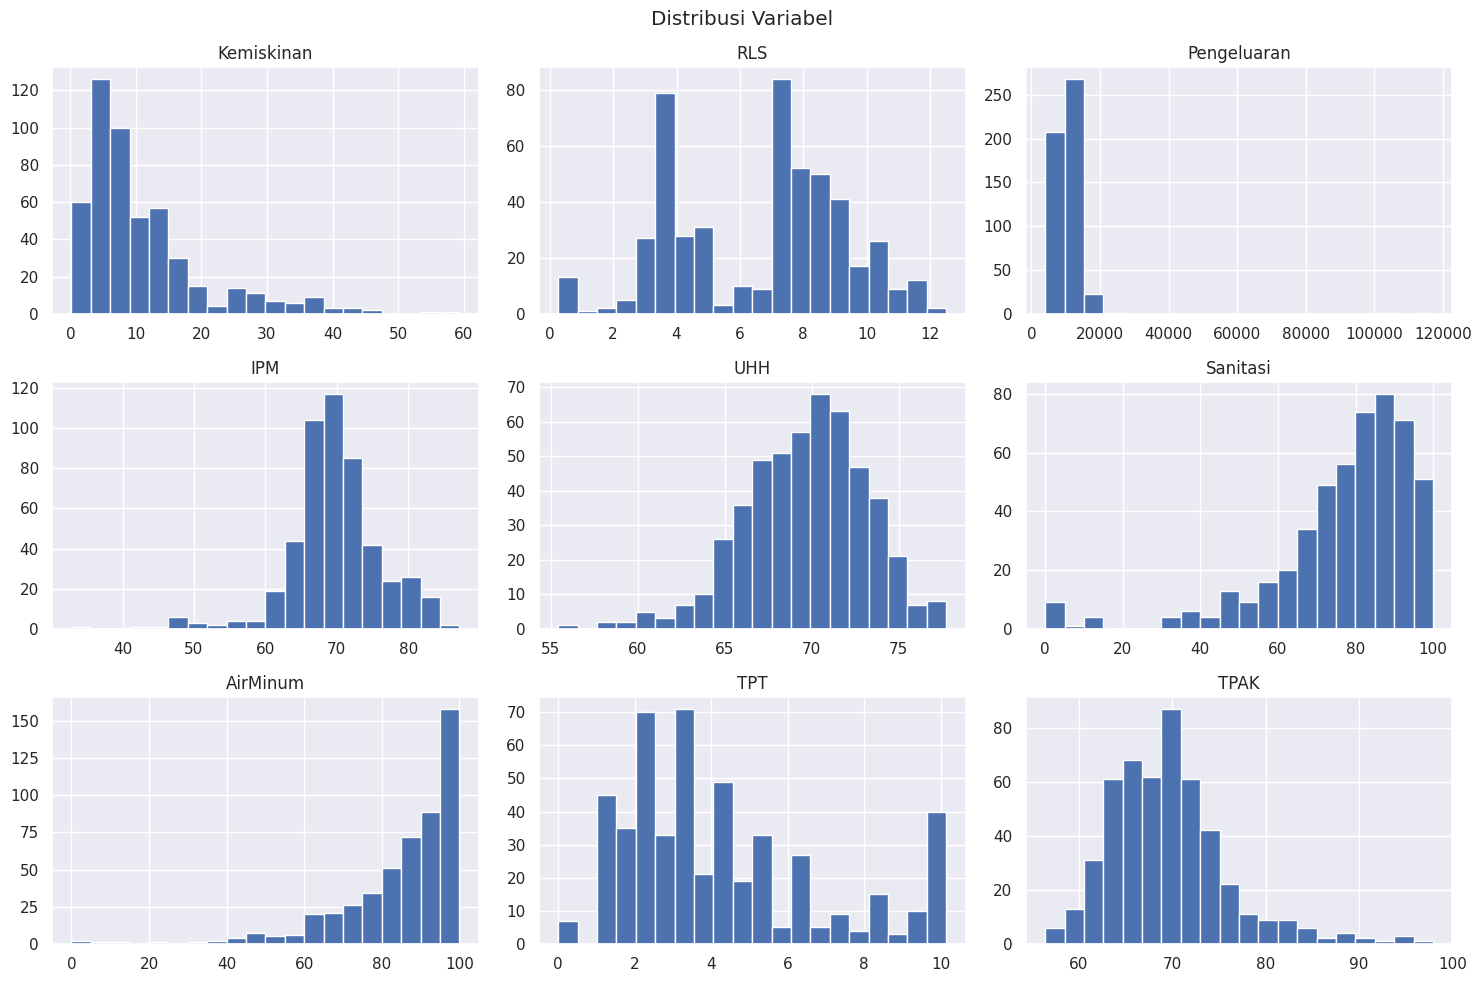

In [ ]:
numerical_cols = [
    'Kemiskinan', 'RLS', 'Pengeluaran',
    'IPM', 'UHH', 'Sanitasi',
    'AirMinum', 'TPT', 'TPAK'
]

df[numerical_cols].hist(
    figsize=(15,10),
    bins=20
)

plt.suptitle('Distribusi Variabel')
plt.tight_layout()
plt.show()

**Insight Distribusi Variabel:**

> Sebagian besar variabel numerik menunjukkan distribusi yang tidak simetris (skewed). **Kemiskinan** dan **TPT** condong ke kanan (right-skewed) — mayoritas wilayah memiliki tingkat kemiskinan di bawah 15% dan TPT di bawah 6%, namun terdapat sejumlah wilayah dengan nilai yang jauh lebih tinggi. Sebaliknya, **AirMinum** dan **Sanitasi** condong ke kiri (left-skewed), menandakan sebagian besar wilayah sudah memiliki akses sanitasi dan air minum yang cukup baik (mendekati 100%), meski masih ada sejumlah wilayah yang tertinggal jauh di bawah rata-rata. Variabel **IPM** dan **UHH** relatif mendekati distribusi normal dengan sedikit ekor di sisi kiri, mengindikasikan adanya sejumlah kecil wilayah dengan kualitas pembangunan manusia dan kesehatan yang jauh tertinggal dibanding mayoritas wilayah lainnya.


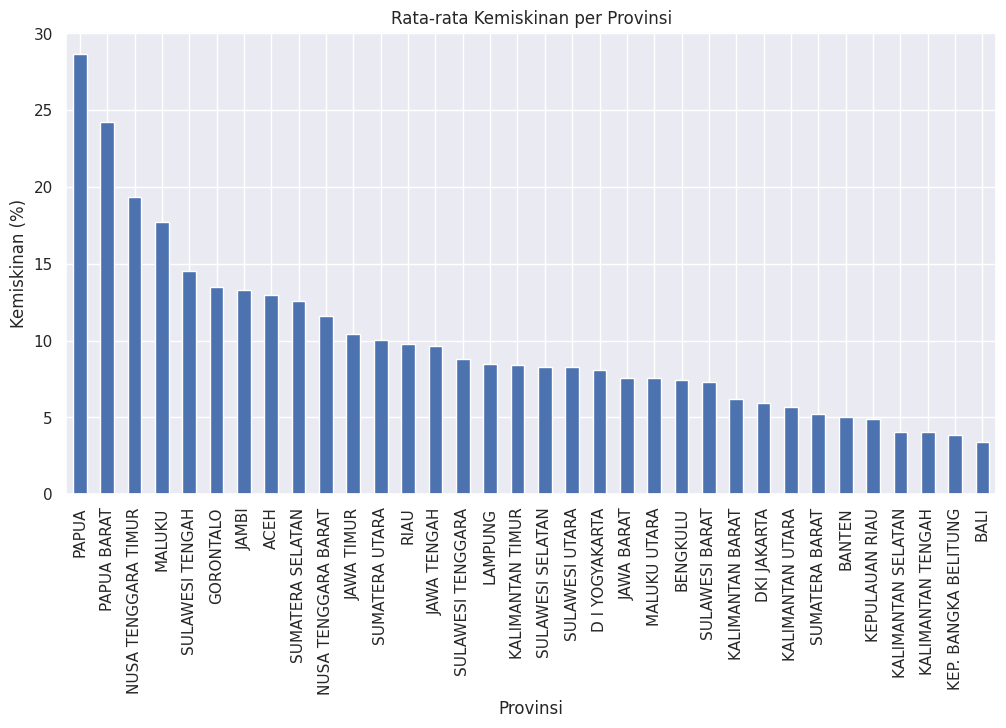

In [ ]:
prov_kemiskinan = (
    df.groupby('Provinsi')['Kemiskinan']
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12,6))
prov_kemiskinan.plot(kind='bar')
plt.title('Rata-rata Kemiskinan per Provinsi')
plt.ylabel('Kemiskinan (%)')
plt.show()

**Insight Kemiskinan per Provinsi:**

> Provinsi **Papua** memiliki rata-rata tingkat kemiskinan tertinggi (±28,6%), diikuti oleh **Papua Barat** (±24,2%), **Nusa Tenggara Timur** (±19,3%), dan **Maluku** (±17,6%). Pola ini menunjukkan tingkat kemiskinan yang jauh lebih tinggi secara konsisten di wilayah Indonesia bagian timur dibandingkan wilayah lain. Sebaliknya, provinsi dengan rata-rata kemiskinan terendah didominasi oleh wilayah **Kalimantan** dan **Bali**, yang mengindikasikan kesenjangan pembangunan antarwilayah yang cukup signifikan di Indonesia dan perlunya perhatian khusus pada kawasan timur Indonesia dalam strategi pengentasan kemiskinan.


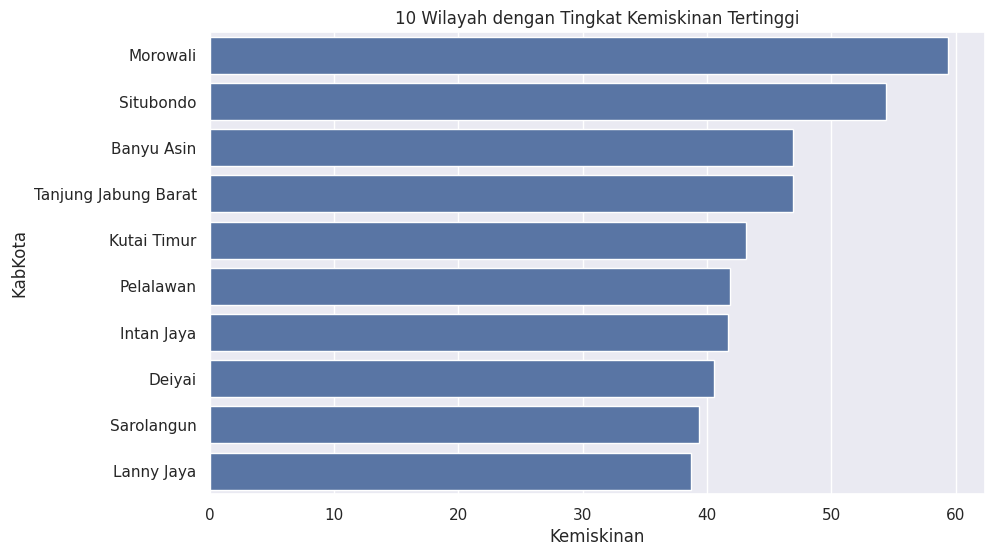

In [ ]:
top10_kemiskinan = (
    df.sort_values(
        'Kemiskinan',
        ascending=False
    )
    .head(10)
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top10_kemiskinan,
    x='Kemiskinan',
    y='KabKota'
)

plt.title('10 Wilayah dengan Tingkat Kemiskinan Tertinggi')

plt.show()

**Insight 10 Wilayah dengan Kemiskinan Tertinggi:**

> Menariknya, wilayah dengan tingkat kemiskinan tertinggi secara individu **tidak seluruhnya berasal dari provinsi dengan rata-rata kemiskinan tertinggi**. Morowali (Sulawesi Tengah) dan Situbondo (Jawa Timur) misalnya, menempati posisi teratas meskipun provinsinya secara rata-rata tidak masuk kelompok termiskin. Hal ini menunjukkan adanya **kantong-kantong kemiskinan (pocket of poverty)** yang tersebar di berbagai wilayah Indonesia, sehingga intervensi kebijakan idealnya tidak hanya menyasar provinsi dengan rata-rata kemiskinan tinggi, tetapi juga perlu berbasis kabupaten/kota secara spesifik.


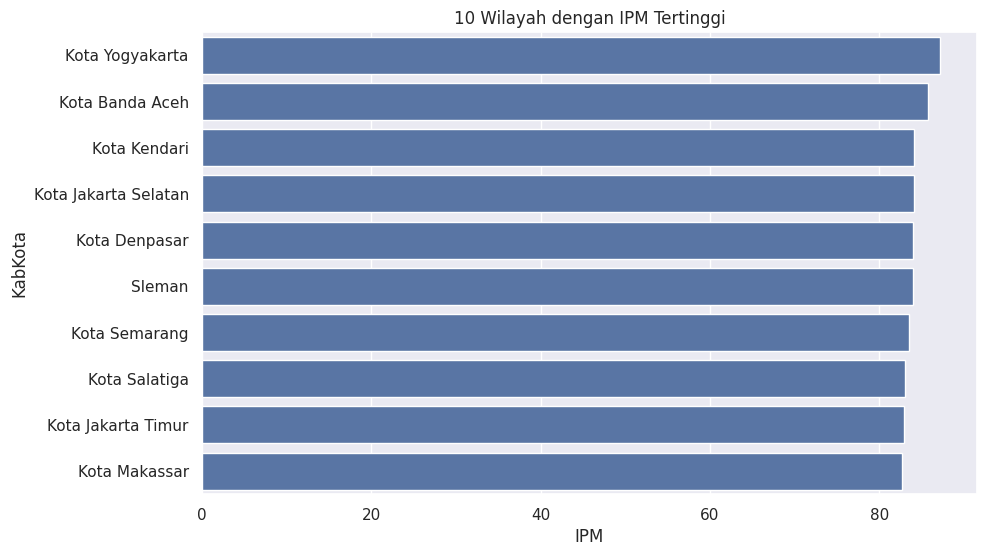

In [ ]:
top10_ipm = (
    df.sort_values(
        'IPM',
        ascending=False
    )
    .head(10)
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top10_ipm,
    x='IPM',
    y='KabKota'
)

plt.title('10 Wilayah dengan IPM Tertinggi')

plt.show()

**Insight 10 Wilayah dengan IPM Tertinggi:**

> Seluruh 10 wilayah dengan IPM tertinggi merupakan wilayah **perkotaan (Kota)**, dipimpin oleh Kota Yogyakarta, Kota Banda Aceh, dan Kota Kendari. Pola ini menegaskan adanya **kesenjangan pembangunan antara wilayah perkotaan dan perdesaan/kabupaten**, di mana kota-kota besar umumnya memiliki akses pendidikan, kesehatan, dan ekonomi yang jauh lebih baik dibandingkan wilayah kabupaten.


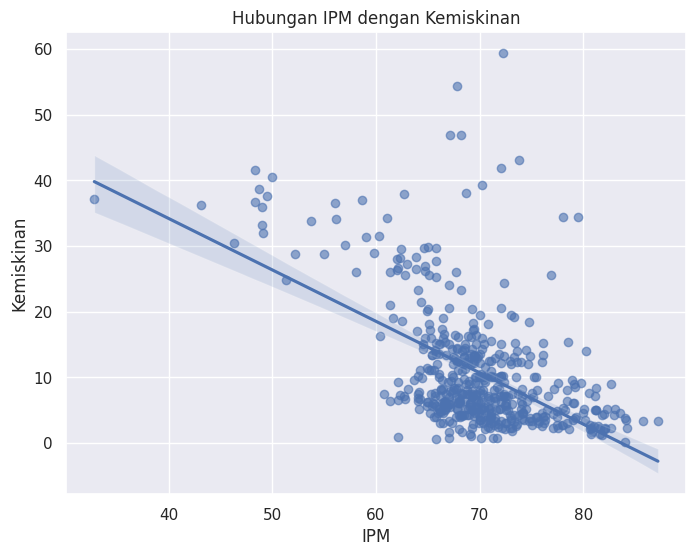

In [ ]:
plt.figure(figsize=(8,6))

sns.regplot(
    data=df,
    x='IPM',
    y='Kemiskinan',
    scatter_kws={'alpha':0.6}
)

plt.title('Hubungan IPM dengan Kemiskinan')
plt.show()

**Insight Hubungan IPM dan Kemiskinan:**

> Scatter plot ini memperkuat temuan pada heatmap korelasi (r = -0,54): semakin tinggi IPM suatu wilayah, kecenderungan tingkat kemiskinannya semakin rendah. Namun demikian, sebaran titik pada rentang IPM 60-75 cukup lebar (mulai dari kemiskinan <10% hingga >40%), yang menunjukkan bahwa **IPM saja belum cukup untuk menjelaskan tingkat kemiskinan suatu wilayah** secara menyeluruh — faktor lain seperti kondisi geografis, akses infrastruktur, dan struktur ekonomi lokal turut berperan dan berpotensi digali lebih lanjut pada tahap pemodelan.


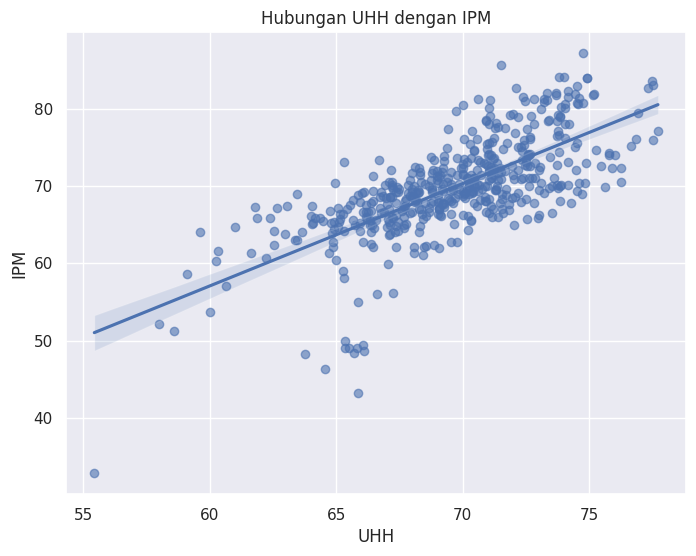

In [ ]:
plt.figure(figsize=(8,6))

sns.regplot(
    data=df,
    x='UHH',
    y='IPM',
    scatter_kws={'alpha':0.6}
)

plt.title('Hubungan UHH dengan IPM')
plt.show()

**Insight Hubungan UHH dan IPM:**

> Hubungan antara UHH (Umur Harapan Hidup) dan IPM menunjukkan pola positif yang kuat dan konsisten (r = 0,71), tervisualisasikan dengan sebaran titik yang cukup rapat mengikuti garis regresi. Ini mengonfirmasi bahwa dimensi kesehatan merupakan salah satu komponen utama yang paling konsisten mendorong nilai IPM suatu wilayah, sejalan dengan metodologi resmi penghitungan IPM oleh BPS.


# D. KESIMPULAN & REKOMENDASI

**Ringkasan Temuan:**

> 1. **Kualitas data**: Dataset awal (532 baris) memiliki missing value pada kolom IPM, UHH, Sanitasi, dan AirMinum (ditangani dengan imputasi median & drop), 16 baris duplikat (dihapus), satu kesalahan input ekstrem pada Kemiskinan Kota Medan (834 → 8,34), serta outlier ekstrem pada TPT yang ditangani dengan clipping (winsorization).
> 2. **Faktor paling berhubungan dengan kemiskinan**: IPM (-0,54), Sanitasi (-0,48), dan UHH (-0,40) merupakan tiga variabel dengan korelasi negatif terkuat terhadap kemiskinan — menegaskan pentingnya pembangunan manusia, kesehatan, dan sanitasi dalam menekan angka kemiskinan.
> 3. **Kesenjangan wilayah**: Kemiskinan tertinggi secara konsisten terpusat di Indonesia bagian timur (Papua, Papua Barat, NTT, Maluku), sementara IPM tertinggi didominasi wilayah perkotaan di Jawa dan kota-kota besar lainnya — menggambarkan kesenjangan pembangunan kota-desa dan barat-timur yang perlu jadi perhatian.
> 4. **Kantong kemiskinan lokal**: Beberapa kabupaten dengan kemiskinan tertinggi (Morowali, Situbondo, Banyu Asin, dll.) berada di provinsi yang rata-ratanya tidak tertinggi, menunjukkan perlunya kebijakan berbasis kabupaten/kota, bukan hanya provinsi.

**Rekomendasi:**

> 1. Prioritaskan program pengentasan kemiskinan pada wilayah dengan IPM, akses sanitasi, dan akses air minum yang rendah, khususnya di Indonesia bagian timur.
> 2. Lakukan investigasi lebih lanjut pada kabupaten/kota dengan kemiskinan tinggi namun berada di provinsi ber-IPM sedang/tinggi, karena berpotensi mengindikasikan masalah lokal spesifik (isolasi geografis, struktur ekonomi, dsb).
> 3. Dataset hasil pembersihan (`dataset_kemiskinan_clean.csv`) dapat digunakan untuk tahap analisis lanjutan, misalnya pemodelan regresi untuk memprediksi tingkat kemiskinan atau clustering wilayah berdasarkan kemiripan indikator sosial-ekonomi.
